# Quick visualization of sea ice concentration and comparison of different products

### Introduction

This notebook tutorial provides a quick introduction to how to read and plot netCDF product files from the Sea Ice Concentration (SIC) Climate Data Records (CDRs), see https://cds.climate.copernicus.eu/datasets/satellite-sea-ice-concentration?tab=overview. 

The supported CDRs are:
* Global Sea Ice Concentration v3.0 based on SMMR / SSMI / SSMIS. Produced by EUMETSAT OSI SAF and consists of a CDR and a supplementing Interim CDR (ICDR):
 * CDR covering the period 1978 - 2020 (product ID “OSI-450-a”),
 * ICDR covering the period 2021 - today (product ID “OSI-430-a”).
*Global Sea Ice Concentration v3.0 based on AMSR-E / AMSR2. Produced by EUMETSAT OSI SAF and consists of a CDR:
 * CDR covering the period 2002 - 2020 (product ID “OSI-458”),

The two products differ in their spatial resolution due to their different input data. In this notebook, we plot the two products next to each other for easy comparison.

Note, that this notebook can easily be extended to include more SIC CDR products e.g. directly from EUMETSAT OSI SAF or ESA CCI.

### How to get started
The outline of the notebook is the following:
1. How to access this notebook, and how to set up the CDS API
2. Prepare data directories for downloading data and the generated output files.
3. Import libraries
4. Define functions for getting the right data and plotting
5. Different examples of visualizations. Note, that for each example, it is possible to save the figure to your local directory.

### How to access this notebook
This tutorial is in the form of a Jupyter notebook, written in Python 3.9.13. Make sure to install the correct software for running this training, as there are a number of free cloud-based services for creating, editing, running, and exporting Jupyter notebooks.

### How to set up the CDS API for downloading data
The Climate Data Store (CDS) Application Program Interface (API) is a service providing programmatic access to download the data from the C3S CDS. 

The next steps are essential for accessing the C3S CDS data and for the notebook to work. The instructions are found at https://cds.climate.copernicus.eu/how-to-api and consist of a few steps:
1. Register an account 
2. Log in on the CDS
3. When logged in: a token ("key") appears. This must be saved locally as described in step 1.3 
4. Install the CDS API client
5. Use the CDS API for data access: Note that you must agree to the Terms of use of a dataset before downloading any data out of it. This step must be done manually from the dataset page (at the bottom of the download form) the first time accessing a new dataset.
    
### Prepare local data directory
The notebook will use the directory variable (which needs to be defined by the user):
MYLOCALDIR = ‘</path/to/local/dir/>’



In [1]:
# NOTE - insert path to your local directory where files can be stored
MYLOCALDIR = '</path/to/local/dir/>'

### Import libraries

In [2]:
import os
import xarray as xr
import numpy as np
import cdsapi
import traceback
import shutil

from datetime import datetime, date, timedelta

from matplotlib import pylab as plt
from matplotlib import cm # matplotlib colormaps
import cmocean # cmocean colormaps
import matplotlib.lines as mlines

### Define functions to access SIC data as an xarray dataset using the CDS API

In [3]:
CDS_REGION = {
    "nh": "northern_hemisphere",
    "sh": "southern_hemisphere",
}

CDR_RULES = {
    "amsr": [
        {
            "name": "amsr-cdr",
            "start": date(2002, 6, 1),
            "end": date(2020, 12, 31),
            "sensor": "amsr",
            "cdr_type": "cdr",
            "version": "3_0",
        },
        {
            "name": "amsr-icdr",
            "start": date(2021, 1, 1),
            "end": lambda: date.today() - timedelta(days=16),
            "sensor": "amsr",
            "cdr_type": "icdr",
            "version": "3_0",
        },
    ],
    "ssmis": [
        {
            "name": "ssmis-cdr",
            "start": date(1978, 10, 25),
            "end": date(2020, 12, 31),
            "sensor": "ssmis",
            "cdr_type": "cdr",
            "version": "3_1",
        },
        {
            "name": "ssmis-icdr",
            "start": date(2021, 1, 1),
            "end": date(2025,9,24),
            "sensor": "ssmis",
            "cdr_type": "icdr",
            "version": "3_0",
        },
    ],
}


def resolve_end(value):
    # treat fixed datasets and evolving datasets the same way, without breaking
    if callable(value):
        return value()
    return value


def get_cdr_rule(dt, instrument):
    if instrument not in CDR_RULES:
        raise ValueError("Unknown instrument {}".format(instrument))

    for rule in CDR_RULES[instrument]:
        if rule["start"] <= dt <= resolve_end(rule["end"]):
            return rule

    raise ValueError(
        "No valid CDR rule for date {} and instrument {}".format(dt, instrument)
    )


def find_apirequest(dt, area, instrument):
    # Define the API request dependent of the date, area, and instrument
    rule = get_cdr_rule(dt, instrument)
    origin  = "eumetsat_osi_saf"
    agg     = "daily"

    if area not in CDS_REGION:
        raise ValueError("Unknown area {}".format(area))

    request = {
        "variable": "all",
        "version": rule["version"],
        "sensor": rule["sensor"],
        "origin": origin,
        "region": [CDS_REGION[area]],
        "cdr_type": [rule["cdr_type"]],
        "temporal_aggregation": agg,
        "year": [f"{dt:%Y}"],
        "month": [f"{dt:%m}"],
        "day": [f"{dt:%d}"],
    }

    return request


def get_sic_filename(dt, area, instrument):
    # Get the filename dependent of date, area, and instrument
    rule = get_cdr_rule(dt, instrument)

    version_str = rule["version"].replace("_", "p")  # 3_0 → 3p0

    if rule["name"] == "ssmis-cdr":
        fn = f'ice_conc_{area}_ease2-250_cdr-v{version_str}_{dt:%Y%m%d}1200.nc'
    elif rule["name"] == "ssmis-icdr":
        fn = f'ice_conc_{area}_ease2-250_icdr-v{version_str}_{dt:%Y%m%d}1200.nc'
    elif rule["name"] == "amsr-cdr":
        fn = f'ice_conc_{area}_ease2-250_cdr-v{version_str}-amsr_{dt:%Y%m%d}1200.nc'
    elif rule["name"] == "amsr-icdr":
        fn = f'ice_conc_{area}_ease2-250_icdr-v{version_str}-amsr_{dt:%Y%m%d}1200.nc'
    else:
        raise ValueError(f"Unknown rule {rule['name']}")

    return fn


def get_sic_file(dt, area, instrument, silent=True):
    rule = get_cdr_rule(dt, instrument)
    sic_fn = get_sic_filename(dt, area, instrument)

    sicfile = os.path.join(MYLOCALDIR, sic_fn)

    if not silent:
        print("MYLOCALDIR:", MYLOCALDIR)
        print("sicfile:", sicfile)
        print("exists:", os.path.isfile(sicfile))
        print("cdr:", rule["name"])
        print("area:", area)
        print("instrument:", instrument)
    
    if not os.path.isfile(sicfile):
        dataset = "satellite-sea-ice-concentration"
        request = find_apirequest(dt, area, instrument)
        client = cdsapi.Client()
        dir_tmp = MYLOCALDIR
        filename_tmp = os.path.join(dir_tmp, "zipfile.zip")

        if not silent:
            print("dataset:", dataset)
            print("request:", request)
            print("filename_tmp:", filename_tmp)
            print("dir exists:", os.path.isdir(dir_tmp))
            print("dir writable:", os.access(dir_tmp, os.W_OK))

        try:
            client.retrieve(dataset, request, filename_tmp)
        except Exception as e:
            print("ERROR TYPE:", type(e).__name__)
            print("ERROR:", e)
            traceback.print_exc()
            raise

        shutil.unpack_archive(filename_tmp, dir_tmp)
        os.remove(filename_tmp)

    if not os.path.isfile(sicfile):
        raise ValueError(sicfile, "not found")

    return sicfile

### Define functions to make SIC maps
The simple_plot makes a map of the sea-ice concentration.
The plot_two_contours makes a map of the sea-ice edge for two different dates.

In [4]:
def simple_plot(dt,area,instrument,dt2=None,ax=None,cmap=None,cbar=None,savefig=False):
    # Function plotting a simple map of the data
    # Inputs are date, area, instrument
    # Optional inputs are reference-date, axes, colormap, colorbar, save-figure
    
    rule = get_cdr_rule(dt, instrument)
    print(
        f"[simple_plot] {instrument.upper()} {rule['cdr_type']} "
        f"({area}) dt={dt:%Y-%m-%d}" +
        (f", dt2={dt2:%Y-%m-%d}" if dt2 else "")
    )
    
    # Read input data
    ds = xr.open_dataset( get_sic_file(dt,area,instrument) )

    # Setting the colormap
    if cmap is not None:
        cmap = cmap
    else:
        cmap = cm.PuBu_r

    # In case of an anomaly map, the colormap is adjusted for this    
    if dt2 is not None:
        try:
            ds2 = xr.open_dataset( get_sic_file(dt2,area,instrument) )
            cmap = cmocean.cm.balance_r
        except:
            ds2 = None
            print(f'Warning - could not locate/read data2 for {dt2:%Y%m%d},{area},{instrument}')
    cmap = cmap.with_extremes(bad='grey')
    
    # Setting the figure layout
    if ax is None:
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(1,1,1)

    # Reading the ice concentration data, and setting
    # minimum and maximum values
    field = ds['ice_conc'][0]
    vmin,vmax = 0,100
    if dt2 is not None and ds.attrs['keywords'] == ds2.attrs['keywords']:
        field = ds['ice_conc'][0] - ds2['ice_conc'][0]
        vmin,vmax = -100,100
        
    # Plotting
    im = ax.imshow(field, interpolation='none',vmin=vmin,vmax=vmax,cmap=cmap)
        
    # remove x/y-ticks
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Figure title
    region_name = CDS_REGION[area].replace("_", " ").title()
    version_str = rule["version"].replace("_", ".")

    ax.set_title(f"{region_name} - {instrument.upper()} v{version_str}")
    
    # Add date label in top-right corner
    if dt2 is None:
        label = f"{dt:%Y-%m-%d}"
        color = "w"
    else:
        label = f"{dt:%Y-%m-%d} - {dt2:%Y-%m-%d}"
        color = "k"

    ax.text(
        0.98, 0.98, label,
        va="top", ha="right",
        transform=ax.transAxes,
        color=color,
        fontsize=12
    )
        
    # Colorbar, if not None
    if cbar == 'vertical' or cbar == 'horizontal':
        # Add a colorbar next to the map
        cb = plt.colorbar(im, ax=ax, orientation=cbar, shrink=0.8, pad=0.05)  # Adjust shrink and pad for positioning
        cb.set_label('Sea Ice Concentration (%)',fontsize=12, color='k')
        cb.ax.tick_params(labelsize=9,colors='k')
        
    # Show the plot
    plt.tight_layout()
    
    # Save figure, if not None
    if savefig:
        plt.savefig('Simple_SIC-map.png', bbox_inches='tight', dpi=150)
        print('Figure is saved')

    return ax


def plot_two_contours(date1,date2,area,instrument,linecols=['C0','C1'],conclev=0.5,savefig=False):
    # Function plotting the sea-ice edge of two different dates.
    # Inputs are date1 and date2, area, instrument.
    # Optional inputs are line-colors, concentration-of-line, save-figure
    
    rule = get_cdr_rule(date1, instrument)
    print(
        f"[plot_two_contours] {instrument.upper()} {rule['cdr_type']} "
        f"({area}) date1={date1:%Y-%m-%d}, date2={date2:%Y-%m-%d}"
    )
    
    # Read input data for different dates
    ds_1 =  xr.open_dataset(get_sic_file(date1,area,instrument))
    ds_2 =  xr.open_dataset(get_sic_file(date2,area,instrument))

    # Setting the figure layout
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(1,1,1)
  
    # plot the sea ice contour, and the lines for the legendfor key, value in dict.items():        
    ax.contour(ds_1['ice_conc'][0], levels=(conclev,), colors=linecols[0], origin='upper',)
    ln_1 = mlines.Line2D([], [], color=linecols[0], label=f"{date1:%Y-%m-%d}")

    ax.contour(ds_2['ice_conc'][0], levels=(conclev,), colors=linecols[1], origin='upper')
    ln_2 = mlines.Line2D([], [], color=linecols[1], label=f"{date2:%Y-%m-%d}")

    # add contour of the landmask
    landmask=ds_2['ice_conc'][0].to_masked_array().mask
    ax.contour(landmask.astype('float'), levels=(0.5,), colors='k', origin='upper')

    # add the legend
    ax.legend(handles=[ln_1, ln_2])

    # remove x/y-ticks
    ax.set_xticks([])
    ax.set_yticks([])

    # Figure title
    region_name = CDS_REGION[area].replace("_", " ").title()
    version_str = rule["version"].replace("_", ".")

    ax.set_title(f"{region_name} - {instrument.upper()} v{version_str}")
        
    # Save figure, if not None
    if savefig:
        plt.savefig('SIC-map-with-contours.png', bbox_inches='tight', dpi=150)
        print('Figure is saved')

    return ax    

### Search for data, download, open with xarray
Searches for product file for given date, hemisphere and instrument. If the file does not alreay exist on given directory, it will be downloaded.

In [5]:
# This block is an example of how to check a SIC file for given date dt and area (NH or SH)
# and instrument (SSMIS or AMSR). 
# If the product file does not already exist at mylocaldir, it is downloaded from cdsapi.
# With print command it is possible to see what the content of the file.

dt = date(2024,12,2)
area = 'nh'
instrument = 'ssmis'

sicfile = get_sic_file(dt, area, instrument, silent=False)
ds = xr.open_dataset(sicfile)
print(ds)

MYLOCALDIR: </path/to/local/dir/>
sicfile: </path/to/local/dir/>/ice_conc_nh_ease2-250_icdr-v3p0_202412021200.nc
exists: False
cdr: ssmis-icdr
area: nh
instrument: ssmis
dataset: satellite-sea-ice-concentration
request: {'variable': 'all', 'version': '3_0', 'sensor': 'ssmis', 'origin': 'eumetsat_osi_saf', 'region': ['northern_hemisphere'], 'cdr_type': ['icdr'], 'temporal_aggregation': 'daily', 'year': ['2024'], 'month': ['12'], 'day': ['02']}
filename_tmp: </path/to/local/dir/>/zipfile.zip
dir exists: False
dir writable: False


2026-05-26 12:49:52,050 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-05-26 12:49:52,051 INFO Request ID is ed3b5f4c-5bab-418b-915f-962d5bbc4f11
2026-05-26 12:49:52,256 INFO status has been updated to accepted
2026-05-26 12:50:13,707 INFO status has been updated to running
2026-05-26 12:50:25,200 INFO status has been updated to successful


a62776c8931cd187584b903385e8c1e7.zip:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

ERROR TYPE: FileNotFoundError
ERROR: [Errno 2] No such file or directory: '</path/to/local/dir/>/zipfile.zip'


Traceback (most recent call last):
  File "/var/folders/kx/ksg5wbrj1sq95rp2tz_72j6c0000gn/T/ipykernel_1340/3493130271.py", line 140, in get_sic_file
    client.retrieve(dataset, request, filename_tmp)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/datapi/legacy_api_client.py", line 179, in retrieve
    return submitted if target is None else submitted.download(target)
                                            ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/datapi/processing.py", line 659, in download
    robust_download(url, target)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/multiurl/http.py", line 479, in wrapped
    r = call(main_url, *args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/datapi/processing.py", line 625, in _download
    multi

FileNotFoundError: [Errno 2] No such file or directory: '</path/to/local/dir/>/zipfile.zip'

### Example 1: Simple quicklooks
In this example is shown how to plot a single maps, and how to plot two maps side-by-side. In the top of each sub-example, the user can define what to be plotted, such as:
* What date
* What hemisphere. “nh” for the Northern Hemisphere or “sh” for the Southern Hemisphere.
* What product (instrument)
* What colors are to be used (colormap for the sea ice concentration, default: PuBu_r)
* Adding colorbar
* Save figure (True / False, default: False)


In [6]:
# 1a. Plot 1 panel

# Settings defined by user
dt = date(2024,12,2)
area = 'nh'
instrument = 'ssmis'
cmap = cm.PuBu_r
cbar = 'vertical'
savefig = False

# Plotting
simple_plot(dt,area,instrument,cmap=cmap,cbar=cbar)

plt.show()

[simple_plot] SSMIS icdr (nh) dt=2024-12-02


2026-05-26 12:50:42,494 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-05-26 12:50:42,496 INFO Request ID is c51d7de6-aa11-4eb8-9def-9977eb7bc6e0
2026-05-26 12:50:42,576 INFO status has been updated to accepted
2026-05-26 12:50:56,229 INFO status has been updated to running
2026-05-26 12:51:03,919 INFO status has been updated to successful


a62776c8931cd187584b903385e8c1e7.zip:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

ERROR TYPE: FileNotFoundError
ERROR: [Errno 2] No such file or directory: '</path/to/local/dir/>/zipfile.zip'


Traceback (most recent call last):
  File "/var/folders/kx/ksg5wbrj1sq95rp2tz_72j6c0000gn/T/ipykernel_1340/3493130271.py", line 140, in get_sic_file
    client.retrieve(dataset, request, filename_tmp)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/datapi/legacy_api_client.py", line 179, in retrieve
    return submitted if target is None else submitted.download(target)
                                            ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/datapi/processing.py", line 659, in download
    robust_download(url, target)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/multiurl/http.py", line 479, in wrapped
    r = call(main_url, *args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/datapi/processing.py", line 625, in _download
    multi

FileNotFoundError: [Errno 2] No such file or directory: '</path/to/local/dir/>/zipfile.zip'

[simple_plot] SSMIS icdr (nh) dt=2024-12-02


2026-05-26 12:51:11,378 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-05-26 12:51:11,380 INFO Request ID is d0213e9b-77da-432b-8ed9-407b78f501f5
2026-05-26 12:51:11,466 INFO status has been updated to accepted
2026-05-26 12:51:25,100 INFO status has been updated to running
2026-05-26 12:51:32,813 INFO status has been updated to successful


a62776c8931cd187584b903385e8c1e7.zip:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

ERROR TYPE: FileNotFoundError
ERROR: [Errno 2] No such file or directory: '</path/to/local/dir/>/zipfile.zip'


Traceback (most recent call last):
  File "/var/folders/kx/ksg5wbrj1sq95rp2tz_72j6c0000gn/T/ipykernel_1340/3493130271.py", line 140, in get_sic_file
    client.retrieve(dataset, request, filename_tmp)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/datapi/legacy_api_client.py", line 179, in retrieve
    return submitted if target is None else submitted.download(target)
                                            ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/datapi/processing.py", line 659, in download
    robust_download(url, target)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/multiurl/http.py", line 479, in wrapped
    r = call(main_url, *args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/datapi/processing.py", line 625, in _download
    multi

FileNotFoundError: [Errno 2] No such file or directory: '</path/to/local/dir/>/zipfile.zip'

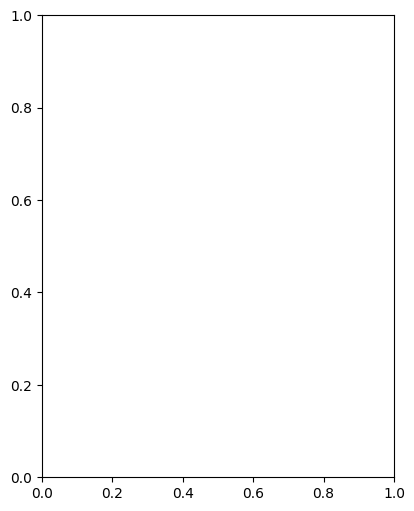

In [7]:
# 1b. Plot two panels side-by-side

# Settings defined by user
dt1 = dt2 = date(2024,12,2)
area1, area2 = 'nh', 'sh'
instrument1 = instrument2= 'ssmis'
cmap = cmocean.cm.ice # instead of default=cm.PuBu_r
cbar = 'horizontal'
savefig = False

# Plotting
fig = plt.figure(figsize=(10,6))

# left figure
ax = fig.add_subplot(1,2,1)
simple_plot(dt1, area1, instrument1, ax=ax, cmap=cmap,cbar=cbar)

# right figure
ax = fig.add_subplot(1,2,2)
simple_plot(dt2, area2, instrument2, ax=ax, cmap=cmap,cbar=cbar)

plt.show()

[simple_plot] SSMIS icdr (nh) dt=2024-12-03


2026-05-26 12:52:23,193 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-05-26 12:52:23,195 INFO Request ID is a739ec7c-5ae1-4be2-a9a2-42463d8c48eb
2026-05-26 12:52:23,285 INFO status has been updated to accepted
2026-05-26 12:52:31,773 INFO status has been updated to running
2026-05-26 12:52:44,618 INFO status has been updated to successful


4716da04163d708c8a7dff1b7b94d058.zip:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

ERROR TYPE: FileNotFoundError
ERROR: [Errno 2] No such file or directory: '</path/to/local/dir/>/zipfile.zip'


Traceback (most recent call last):
  File "/var/folders/kx/ksg5wbrj1sq95rp2tz_72j6c0000gn/T/ipykernel_1340/3493130271.py", line 140, in get_sic_file
    client.retrieve(dataset, request, filename_tmp)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/datapi/legacy_api_client.py", line 179, in retrieve
    return submitted if target is None else submitted.download(target)
                                            ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/datapi/processing.py", line 659, in download
    robust_download(url, target)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/multiurl/http.py", line 479, in wrapped
    r = call(main_url, *args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/datapi/processing.py", line 625, in _download
    multi

FileNotFoundError: [Errno 2] No such file or directory: '</path/to/local/dir/>/zipfile.zip'

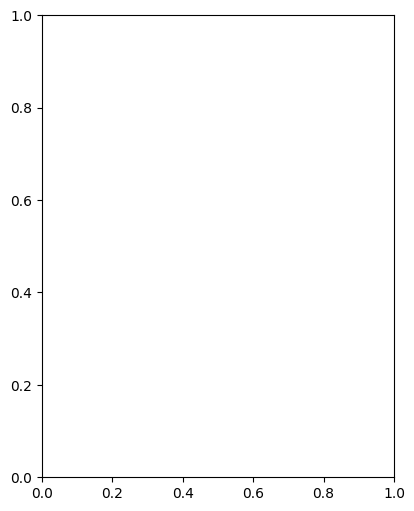

In [8]:
# 1c. 
# Plot two panels side-by-side - one of the SIC field and
# the other showing its difference against a corresponding
# SIC field for another date

# Settings defined by user
dt1, dt2 = date(2024,12,3), date(1978,12,3)
area = 'nh'
instrument = 'ssmis'
cbar='horizontal'
savefig = False

# Plotting
fig = plt.figure(figsize=(10,6))

# left figure
ax = fig.add_subplot(1,2,1)
simple_plot(dt1, area, instrument, ax=ax, cbar=cbar)

# right figure
#ds2 = xr.open_dataset(get_sic_file(dt,'sh','ssmis'))
ax = fig.add_subplot(1,2,2)
simple_plot(dt1, area, instrument, dt2=dt2, ax=ax, cbar=cbar)

plt.show()

### Example 2: Visualise the sea-ice cover with contours
In this example, we visualize the sea-ice cover for a date in two different years with contours instead. In the top of the cell, the user can define what to be plotted, such as:
* What hemisphere. “nh” for the Northern Hemisphere or “sh” for the Southern Hemisphere.
* What product (instrument).
* What date and what years are to be compared.
* What concentration level is to be used for the contour? The default is 0.5 %, representing the ice edge.
* What colors are to be used (colors for the contours), if not using default.


In [9]:
# Settings defined by user
area = 'nh'
instrument = 'ssmis'
date1 = date(1980,9,15)
date2 = date(2000,9,15)
#conclev  = 30 
#linecols = ['red','orange']

# Plotting
plot_two_contours(date1,date2,area,instrument) #,conclev = conclev,linecols=linecols)

plt.show()

[plot_two_contours] SSMIS cdr (nh) date1=1980-09-15, date2=2000-09-15


2026-05-26 12:52:51,713 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-05-26 12:52:51,715 INFO Request ID is 86280059-9121-4c46-ae7c-3ca88dab1e0e
2026-05-26 12:52:51,790 INFO status has been updated to accepted
2026-05-26 12:53:05,404 INFO status has been updated to running
2026-05-26 12:53:13,087 INFO status has been updated to successful


2ee04a9454f7c7cde01c860bafe158db.zip:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

ERROR TYPE: FileNotFoundError
ERROR: [Errno 2] No such file or directory: '</path/to/local/dir/>/zipfile.zip'


Traceback (most recent call last):
  File "/var/folders/kx/ksg5wbrj1sq95rp2tz_72j6c0000gn/T/ipykernel_1340/3493130271.py", line 140, in get_sic_file
    client.retrieve(dataset, request, filename_tmp)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/datapi/legacy_api_client.py", line 179, in retrieve
    return submitted if target is None else submitted.download(target)
                                            ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/datapi/processing.py", line 659, in download
    robust_download(url, target)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/multiurl/http.py", line 479, in wrapped
    r = call(main_url, *args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/datapi/processing.py", line 625, in _download
    multi

FileNotFoundError: [Errno 2] No such file or directory: '</path/to/local/dir/>/zipfile.zip'

### Example 3: Compare different sea-ice concentration products and plot regional maps
In this example, we compare two different products for the same date. We also define a subset of the data to only plot regional maps. The example is good for visualizing the different spatial resolutions of the two products. In the top of the cell, the user can define what to be plotted, such as:
* What hemisphere. “nh” for the Northern Hemisphere or “sh” for the Southern Hemisphere.
* What region to zoom in to? As a default example, the Ross Sea in the southern hemisphere is defined.
* What date?
* What products are to be compared? 
* What colors are to be used (colormap for the sea ice concentration)?


[simple_plot] SSMIS cdr (sh) dt=2020-08-24


2026-05-26 12:53:24,184 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-05-26 12:53:24,186 INFO Request ID is 78720c04-cf00-4de8-87c2-db55a25e6ee7
2026-05-26 12:53:24,294 INFO status has been updated to accepted
2026-05-26 12:53:38,069 INFO status has been updated to running
2026-05-26 12:53:45,775 INFO status has been updated to successful


56e10881915ec1afe8cde3c208da517e.zip:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

ERROR TYPE: FileNotFoundError
ERROR: [Errno 2] No such file or directory: '</path/to/local/dir/>/zipfile.zip'


Traceback (most recent call last):
  File "/var/folders/kx/ksg5wbrj1sq95rp2tz_72j6c0000gn/T/ipykernel_1340/3493130271.py", line 140, in get_sic_file
    client.retrieve(dataset, request, filename_tmp)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/datapi/legacy_api_client.py", line 179, in retrieve
    return submitted if target is None else submitted.download(target)
                                            ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/datapi/processing.py", line 659, in download
    robust_download(url, target)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/multiurl/http.py", line 479, in wrapped
    r = call(main_url, *args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/datapi/processing.py", line 625, in _download
    multi

FileNotFoundError: [Errno 2] No such file or directory: '</path/to/local/dir/>/zipfile.zip'

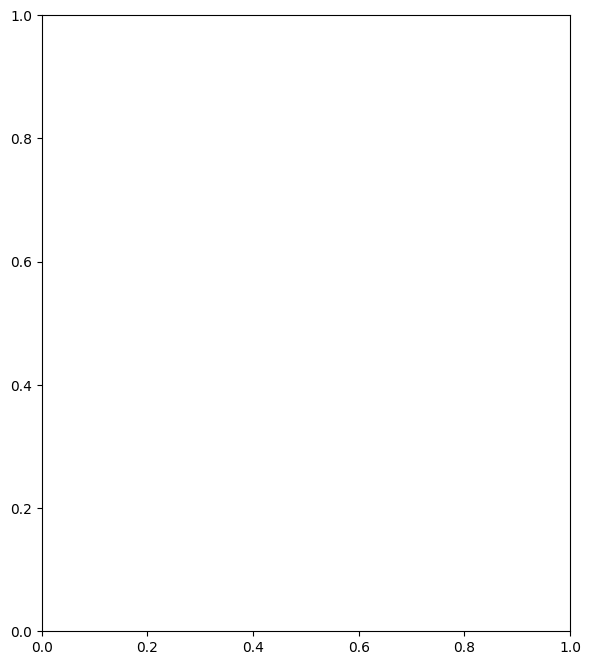

In [10]:
# Settings defined by user
dt = date(2020,8,24)
area = 'sh'
if area == 'nh':
    # Default region is centered on Svalbard
    xlim = (175,275)
    ylim = (300,200)
elif area == 'sh':
    # Default region is centered on Ross Sea
    xlim = (125,250)
    ylim = (375,250)
instr_ssmis = 'ssmis'
instr_amsr = 'amsr'
#cmap = cm.PuBu_r
savefig = False

# Plotting
fig = plt.figure(figsize=(15,8))

# left figure
ax = fig.add_subplot(1,2,1)
simple_plot(dt,area,instr_ssmis, ax=ax)

# right figure
ax = fig.add_subplot(1,2,2, sharex=ax, sharey=ax)
simple_plot(dt,area,instr_amsr, ax=ax)

# Only map subset of data (Zoom)
for ax in fig.axes:
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

plt.show()

if savefig:
    plt.savefig('Comparison_SIC.png', bbox_inches='tight', dpi=150)

### Example 4: Read and plot regional maps for some recent dates
The ICDR product is updated daily and has a latency of 16 days. In this example, we plot side-by-side three regional maps for three recent dates. In the top of the cell, the user can define what to be plotted, such as:
* What hemisphere. “nh” for the Northern Hemisphere or “sh” for the Southern Hemisphere.
* What region to zoom in to? As a default example, a region centered at Svalbard in the northern hemisphere is defined.
* What dates
* What products to be compared 
* What colors are to be used (colormap for the sea ice concentration, default: PuBu_r)


In [ ]:
# Settings defined by user
area = 'nh'
instrument = 'ssmis'
dt0 = datetime.today().date() - timedelta(days=337)
dt1 = datetime.today().date() - timedelta(days=374)
dt2 = datetime.today().date() - timedelta(days=405)

#change xlim and ylim if other than default area:
if area == 'nh':
    # Default region is centered on Svalbard
    xlim = (175,275)
    ylim = (300,200)
elif area == 'sh':
    # Default region is centered on Ross Sea
    xlim = (125,250)
    ylim = (375,250)

cmap = cm.PuBu_r

# Plotting
fig = plt.figure(figsize=(15,8))

# left figure
ax = fig.add_subplot(1,3,1)
simple_plot(dt2,area,instrument, ax=ax, cmap=cmap)

# mid figure
ax = fig.add_subplot(1,3,2, sharex=ax, sharey=ax)
simple_plot(dt1,area,instrument, ax=ax, cmap=cmap)

# right figure
ax = fig.add_subplot(1,3,3, sharex=ax, sharey=ax)
simple_plot(dt0,area,instrument, ax=ax, cmap=cmap)

# Only map subset of data (Zoom)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
                          
plt.show()               